# Fatigue Behavioral Clean Rerun for Reviewer 2 Comment 4 Notebook

## 1. Imports and configuration

In [2]:
import os
import re
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Deep-learning training configuration
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 7
BATCH_SIZE = 64


DATA_PATH = Path("eye_features.csv")  # Put this notebook in the same folder as eye_features.csv
OUT_DIR = Path("results_clean")
OUT_DIR.mkdir(exist_ok=True)

SEQ_LENS = [10, 20, 30]
EAR_THRESHOLD = 0.21
ROLLING_WINDOW = 5

print("Ready. Output folder:", OUT_DIR.resolve())

Ready. Output folder: C:\Users\LATITUDE E7470\Desktop\ajcodes\research\fatigueanalysis1\results_clean


## 2. Load the processed EAR dataset

In [3]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())
print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

Dataset shape: (65929, 3)
Columns: ['image_name', 'ear', 'label']
                                      image_name       ear  label
0  001_glasses_sleepyCombination_1000_drowsy.jpg  0.284489      1
1  001_glasses_sleepyCombination_1001_drowsy.jpg  0.297797      1
2  001_glasses_sleepyCombination_1002_drowsy.jpg  0.298301      1
3  001_glasses_sleepyCombination_1003_drowsy.jpg  0.288216      1
4  001_glasses_sleepyCombination_1004_drowsy.jpg  0.281307      1

Label distribution:
label
0    29906
1    36023
Name: count, dtype: int64


## 3. Extract subject, stream, and frame information

The filename pattern contains the real driver identifier at the beginning of each image filename, for example `001_glasses_sleepyCombination_1000_drowsy.jpg`. This notebook uses the first three digits as the actual driver/subject group. The stream identifier prevents sequence windows from crossing between different driver-scenario segments.

In [4]:
def parse_filename(name: str):
    stem = Path(str(name)).stem
    # Driver ID is the first 3 digits before the first underscore
    m_subject = re.match(r"^(\d{3})_", stem)
    subject_id = m_subject.group(1) if m_subject else "unknown"

    # Frame number is the last numeric token before the label token
    tokens = stem.split("_")
    frame_no = None
    for tok in reversed(tokens):
        if tok.isdigit():
            frame_no = int(tok)
            break

    # Remove trailing frame number and label token to create a stream id
    # Example: 001_glasses_sleepyCombination_1000_drowsy -> 001_glasses_sleepyCombination
    stream = re.sub(r"_\d+_(drowsy|notDrowsy|not_drowsy|alert|nonDrowsy|non_drowsy)$", "", stem, flags=re.IGNORECASE)
    return subject_id, stream, frame_no

parsed = df["image_name"].apply(parse_filename)
df["subject_id"] = parsed.apply(lambda x: x[0])
df["stream_id"] = parsed.apply(lambda x: x[1])
df["frame_no"] = parsed.apply(lambda x: x[2])

# Sort by stream and frame number to preserve temporal ordering
df = df.sort_values(["subject_id", "stream_id", "frame_no", "image_name"]).reset_index(drop=True)

print("Unique subjects:", sorted(df["subject_id"].unique()))
print("Number of streams:", df["stream_id"].nunique())
print("\nSamples per subject and class:")
print(pd.crosstab(df["subject_id"], df["label"]))
print("\nExample parsed rows:")
print(df[["image_name", "subject_id", "stream_id", "frame_no", "ear", "label"]].head(10))

Unique subjects: ['001', '002', '005', '006']
Number of streams: 27

Samples per subject and class:
label          0      1
subject_id             
001         9336   9578
002         7829  10595
005         8843  13087
006         3898   2763

Example parsed rows:
                                         image_name subject_id  \
0  001_glasses_nonsleepyCombination_0_notdrowsy.jpg        001   
1  001_glasses_nonsleepyCombination_1_notdrowsy.jpg        001   
2  001_glasses_nonsleepyCombination_2_notdrowsy.jpg        001   
3  001_glasses_nonsleepyCombination_3_notdrowsy.jpg        001   
4  001_glasses_nonsleepyCombination_4_notdrowsy.jpg        001   
5  001_glasses_nonsleepyCombination_5_notdrowsy.jpg        001   
6  001_glasses_nonsleepyCombination_6_notdrowsy.jpg        001   
7  001_glasses_nonsleepyCombination_7_notdrowsy.jpg        001   
8  001_glasses_nonsleepyCombination_8_notdrowsy.jpg        001   
9  001_glasses_nonsleepyCombination_9_notdrowsy.jpg        001   

       

## 4. Feature engineering

Features are generated within each stream to avoid leakage across different driver-scenario segments. The four core features reproduce the original behavioral model: raw EAR, rolling mean EAR, frame-to-frame EAR change, and binary eye-closure flag.

In [5]:
def add_temporal_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out["ear_rolling_mean"] = out.groupby("stream_id")["ear"].transform(
        lambda s: s.rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    )
    out["ear_delta"] = out.groupby("stream_id")["ear"].diff().fillna(0)
    out["eye_closed"] = (out["ear"] < EAR_THRESHOLD).astype(int)
    return out

df = add_temporal_features(df)
FEATURE_COLS = ["ear", "ear_rolling_mean", "ear_delta", "eye_closed"]
print(df[FEATURE_COLS + ["label", "subject_id", "stream_id"]].head())
print("\nFeature summary:")
print(df[FEATURE_COLS].describe())

        ear  ear_rolling_mean  ear_delta  eye_closed  label subject_id  \
0  0.287188          0.287188   0.000000           0      0        001   
1  0.297649          0.292418   0.010461           0      0        001   
2  0.286146          0.290327  -0.011503           0      0        001   
3  0.293520          0.291126   0.007374           0      0        001   
4  0.290787          0.291058  -0.002733           0      0        001   

                          stream_id  
0  001_glasses_nonsleepyCombination  
1  001_glasses_nonsleepyCombination  
2  001_glasses_nonsleepyCombination  
3  001_glasses_nonsleepyCombination  
4  001_glasses_nonsleepyCombination  

Feature summary:
                ear  ear_rolling_mean     ear_delta    eye_closed
count  65929.000000      65929.000000  65929.000000  65929.000000
mean       0.264725          0.264729     -0.000001      0.095011
std        0.048999          0.047643      0.014940      0.293233
min        0.029880          0.057453     -0.

## 5. Sequence generation without stream crossing

Each sequence is created inside a single stream only. The sequence label is taken from the final frame in the temporal window, matching the original implementation logic.

In [6]:
def make_sequences(data: pd.DataFrame, seq_len: int, feature_cols=FEATURE_COLS):
    X, y, groups, stream_ids = [], [], [], []
    for stream_id, g in data.groupby("stream_id", sort=False):
        g = g.sort_values("frame_no")
        feats = g[feature_cols].values.astype("float32")
        labels = g["label"].values.astype("int32")
        subject = g["subject_id"].iloc[0]
        if len(g) < seq_len:
            continue
        for i in range(len(g) - seq_len + 1):
            X.append(feats[i:i+seq_len])
            y.append(labels[i+seq_len-1])
            groups.append(subject)
            stream_ids.append(stream_id)
    return np.array(X), np.array(y), np.array(groups), np.array(stream_ids)

for L in SEQ_LENS:
    X_tmp, y_tmp, groups_tmp, streams_tmp = make_sequences(df, L)
    print(f"SEQ_LEN={L}: X={X_tmp.shape}, y distribution={dict(zip(*np.unique(y_tmp, return_counts=True)))}, subjects={sorted(np.unique(groups_tmp))}")

SEQ_LEN=10: X=(65686, 10, 4), y distribution={0: 29663, 1: 36023}, subjects=['001', '002', '005', '006']
SEQ_LEN=20: X=(65416, 20, 4), y distribution={0: 29393, 1: 36023}, subjects=['001', '002', '005', '006']
SEQ_LEN=30: X=(65146, 30, 4), y distribution={0: 29123, 1: 36023}, subjects=['001', '002', '005', '006']


In [7]:
# Inspect stream structure and within-stream class composition
stream_summary = (
    df.groupby(["stream_id", "subject_id"])
      .agg(
          n_frames=("frame_no", "size"),
          n_class0=("label", lambda x: (x == 0).sum()),
          n_class1=("label", lambda x: (x == 1).sum())
      )
      .reset_index()
)

stream_summary["pct_class1"] = (
    100 * stream_summary["n_class1"] / stream_summary["n_frames"]
)

stream_summary = stream_summary.sort_values(
    ["subject_id", "stream_id"]
)

print(stream_summary.to_string(index=False))

print("\nNumber of streams:", len(stream_summary))

print("\nStreams per subject:")
print(stream_summary.groupby("subject_id").size())

print("\nOverall frame-level class distribution:")
print(df["label"].value_counts().sort_index())

print("\nOverall frame-level class percentages:")
print(
    (100 * df["label"].value_counts(normalize=True).sort_index()).round(2)
)

                         stream_id subject_id  n_frames  n_class0  n_class1  pct_class1
  001_glasses_nonsleepyCombination        001      3282      3282         0    0.000000
     001_glasses_sleepyCombination        001      2744       599      2145   78.170554
  001_glasses_slowBlinkWithNodding        001      1919       704      1215   63.314226
               001_glasses_yawning        001      1850       843      1007   54.432432
001_noglasses_nonsleepyCombination        001      2684      2684         0    0.000000
   001_noglasses_sleepyCombination        001      2711       330      2381   87.827370
001_noglasses_slowBlinkWithNodding        001      1852       698      1154   62.311015
             001_noglasses_yawning        001      1872       196      1676   89.529915
  002_glasses_nonsleepyCombination        002      2870      2870         0    0.000000
     002_glasses_sleepyCombination        002      2878       314      2564   89.089646
  002_glasses_slowBlinkWithNoddi

## 6. Helper functions for evaluation and plotting

In [8]:
def safe_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def safe_auprc(y_true, y_score):
    try:
        return average_precision_score(y_true, y_score)
    except Exception:
        return np.nan

def compute_metrics(y_true, y_pred, y_score=None):
    if y_score is None:
        y_score = y_pred
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_drowsy": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_drowsy": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_drowsy": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "auroc": safe_auc(y_true, y_score),
        "auprc": safe_auprc(y_true, y_score),
    }

def flatten_sequences(X):
    return X.reshape(X.shape[0], -1)

def save_confusion_matrix(cm, title, path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Not drowsy", "Drowsy"])
    ax.set_yticklabels(["Not drowsy", "Drowsy"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [9]:
def split_train_validation_by_stream(
    X, y, subjects, streams,
    val_fraction=0.15
):
    """
    Create an internal validation partition using complete streams only.

    The selected stream subset is chosen deterministically to:
      1. approximate the requested validation fraction; and
      2. keep the validation class-1 proportion reasonably close
         to that of the complete outer-training partition.

    No stream can occur in both internal training and validation.
    """

    import itertools

    unique_streams = np.array(sorted(pd.unique(streams)))

    total_n = len(y)
    target_n = val_fraction * total_n
    overall_pos_rate = np.mean(y)

    # Stream-level sequence counts and positive-class proportions
    info = []
    for s in unique_streams:
        mask = (streams == s)
        n = int(mask.sum())
        pos = int(y[mask].sum())
        info.append((s, n, pos))

    # With the present dataset, ~15% corresponds naturally to a
    # small number of complete streams. Search subsets of 1–5 streams.
    best_subset = None
    best_score = np.inf

    max_k = min(5, len(unique_streams))

    for k in range(1, max_k + 1):
        for subset in itertools.combinations(info, k):

            n_val = sum(item[1] for item in subset)
            pos_val = sum(item[2] for item in subset)

            if n_val == 0:
                continue

            val_pos_rate = pos_val / n_val

            # Require both classes in validation.
            if pos_val == 0 or pos_val == n_val:
                continue

            size_error = abs(n_val - target_n) / total_n
            class_error = abs(val_pos_rate - overall_pos_rate)

            # Equal emphasis on validation size and class composition.
            score = size_error + class_error

            if score < best_score:
                best_score = score
                best_subset = [item[0] for item in subset]

    if best_subset is None:
        raise ValueError(
            "Could not construct a complete-stream validation subset "
            "containing both classes."
        )

    val_mask = np.isin(streams, best_subset)
    train_mask = ~val_mask

    X_train_internal = X[train_mask]
    y_train_internal = y[train_mask]

    X_val = X[val_mask]
    y_val = y[val_mask]

    # Safety checks
    assert not np.any(
        np.isin(streams[train_mask], streams[val_mask])
    ), "Stream leakage detected between training and validation."

    assert len(np.unique(y_train_internal)) == 2, \
        "Internal training partition does not contain both classes."

    assert len(np.unique(y_val)) == 2, \
        "Validation partition does not contain both classes."

    return (
        X_train_internal,
        y_train_internal,
        X_val,
        y_val,
        best_subset
    )

In [10]:
# Diagnostic check of stream-separated internal validation
TEST_SEQ_LEN = 30
TEST_DRIVER = "001"

X_check, y_check, groups_check, streams_check = make_sequences(
    df, TEST_SEQ_LEN
)

# Reproduce the outer LODO partition
outer_train_mask = groups_check != TEST_DRIVER
outer_test_mask = groups_check == TEST_DRIVER

X_outer_train = X_check[outer_train_mask]
y_outer_train = y_check[outer_train_mask]
groups_outer_train = groups_check[outer_train_mask]
streams_outer_train = streams_check[outer_train_mask]

X_outer_test = X_check[outer_test_mask]
y_outer_test = y_check[outer_test_mask]
streams_outer_test = streams_check[outer_test_mask]

# Create internal train/validation split using complete streams
(
    X_internal_train,
    y_internal_train,
    X_internal_val,
    y_internal_val,
    val_streams
) = split_train_validation_by_stream(
    X_outer_train,
    y_outer_train,
    groups_outer_train,
    streams_outer_train,
    val_fraction=0.15
)

train_streams = np.unique(
    streams_outer_train[
        ~np.isin(streams_outer_train, val_streams)
    ]
)

print("Diagnostic: T =", TEST_SEQ_LEN,
      "| Held-out driver =", TEST_DRIVER)

print("\nOuter training sequences:", len(y_outer_train))
print("Outer test sequences:", len(y_outer_test))

print("\nInternal training sequences:", len(y_internal_train))
print("Internal validation sequences:", len(y_internal_val))
print(
    "Validation percentage:",
    round(100 * len(y_internal_val) / len(y_outer_train), 2),
    "%"
)

print("\nSelected validation streams:")
for s in val_streams:
    print(" ", s)

print("\nInternal training class distribution:",
      dict(zip(*np.unique(y_internal_train, return_counts=True))))

print("Internal validation class distribution:",
      dict(zip(*np.unique(y_internal_val, return_counts=True))))

print(
    "Internal training class-1 percentage:",
    round(100 * np.mean(y_internal_train), 2),
    "%"
)

print(
    "Internal validation class-1 percentage:",
    round(100 * np.mean(y_internal_val), 2),
    "%"
)

print(
    "\nTrain/validation stream overlap:",
    len(set(train_streams).intersection(set(val_streams)))
)

print(
    "Validation/test stream overlap:",
    len(set(val_streams).intersection(set(streams_outer_test)))
)

Diagnostic: T = 30 | Held-out driver = 001

Outer training sequences: 46464
Outer test sequences: 18682

Internal training sequences: 39535
Internal validation sequences: 6929
Validation percentage: 14.91 %

Selected validation streams:
  002_noglasses_nonsleepyCombination
  002_noglasses_slowBlinkWithNodding
  006_glasses_sleepyCombination

Internal training class distribution: {0: 17025, 1: 22510}
Internal validation class distribution: {0: 2994, 1: 3935}
Internal training class-1 percentage: 56.94 %
Internal validation class-1 percentage: 56.79 %

Train/validation stream overlap: 0
Validation/test stream overlap: 0


## 7. Leave-One-Driver-Out evaluation for classical baselines

This is the strongest validation protocol available from the current dataset because it tests each real driver as an unseen subject.

In [11]:
all_results = []
all_predictions = []

for seq_len in SEQ_LENS:
    X, y, groups, stream_ids = make_sequences(df, seq_len)
    subjects = sorted(np.unique(groups))
    print("\n=== Sequence length", seq_len, "===")
    for test_subject in subjects:
        train_idx = groups != test_subject
        test_idx = groups == test_subject
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Scale flattened features using training data only
        scaler = MinMaxScaler()
        X_train_flat = scaler.fit_transform(flatten_sequences(X_train))
        X_test_flat = scaler.transform(flatten_sequences(X_test))

        models = {
            "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
            "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1),
        }

        for model_name, clf in models.items():
            clf.fit(X_train_flat, y_train)
            y_pred = clf.predict(X_test_flat)
            if hasattr(clf, "predict_proba"):
                y_score = clf.predict_proba(X_test_flat)[:, 1]
            else:
                y_score = y_pred
            row = {
                "seq_len": seq_len,
                "model": model_name,
                "test_subject": test_subject,
                "n_train": len(y_train),
                "n_test": len(y_test),
            }
            row.update(compute_metrics(y_test, y_pred, y_score))
            all_results.append(row)
            for yt, yp, ys in zip(y_test, y_pred, y_score):
                all_predictions.append({"seq_len": seq_len, "model": model_name, "test_subject": test_subject, "y_true": int(yt), "y_pred": int(yp), "y_score": float(ys)})
            print(model_name, "test subject", test_subject, "accuracy", round(row["accuracy"], 4), "f1_drowsy", round(row["f1_drowsy"], 4))

results_df = pd.DataFrame(all_results)
preds_df = pd.DataFrame(all_predictions)
results_df.to_csv(OUT_DIR / "classical_lodo_fold_results.csv", index=False)
preds_df.to_csv(OUT_DIR / "classical_lodo_predictions.csv", index=False)

summary_classical = (
    results_df
    .groupby(["seq_len","model"])[
        ["accuracy","precision","recall","f1_drowsy"]
    ]
    .agg(["mean","std"])
    .round(4)
)


=== Sequence length 10 ===
LogisticRegression test subject 001 accuracy 0.5552 f1_drowsy 0.4717
RandomForest test subject 001 accuracy 0.5381 f1_drowsy 0.5965
LogisticRegression test subject 002 accuracy 0.5043 f1_drowsy 0.565
RandomForest test subject 002 accuracy 0.5178 f1_drowsy 0.5633
LogisticRegression test subject 005 accuracy 0.5675 f1_drowsy 0.5749
RandomForest test subject 005 accuracy 0.5327 f1_drowsy 0.5898
LogisticRegression test subject 006 accuracy 0.6756 f1_drowsy 0.7047
RandomForest test subject 006 accuracy 0.5577 f1_drowsy 0.6352

=== Sequence length 20 ===
LogisticRegression test subject 001 accuracy 0.5515 f1_drowsy 0.4647
RandomForest test subject 001 accuracy 0.5546 f1_drowsy 0.6138
LogisticRegression test subject 002 accuracy 0.4966 f1_drowsy 0.5569
RandomForest test subject 002 accuracy 0.5328 f1_drowsy 0.5762
LogisticRegression test subject 005 accuracy 0.5715 f1_drowsy 0.5812
RandomForest test subject 005 accuracy 0.548 f1_drowsy 0.6062
LogisticRegression tes

KeyError: "Columns not found: 'precision', 'recall'"

In [18]:
# Reviewer 2, Comment 5:
# Matched always-drowsy baseline for each T=30 LODO test fold

X30, y30, groups30, streams30 = make_sequences(df, seq_len=30)

rows = []

for driver in sorted(np.unique(groups30)):
    mask = groups30 == driver
    y_test = y30[mask]

    n_total = len(y_test)
    n_drowsy = int(np.sum(y_test == 1))
    n_non_drowsy = int(np.sum(y_test == 0))

    always_drowsy_acc = n_drowsy / n_total

    rows.append({
        "Held-out Driver": driver,
        "Test Sequences": n_total,
        "Non-drowsy": n_non_drowsy,
        "Drowsy": n_drowsy,
        "Always-Drowsy Accuracy": always_drowsy_acc
    })

baseline_df = pd.DataFrame(rows)

print(baseline_df.to_string(index=False))

print(
    "\nMean fold-level always-drowsy accuracy:",
    baseline_df["Always-Drowsy Accuracy"].mean()
)

Held-out Driver  Test Sequences  Non-drowsy  Drowsy  Always-Drowsy Accuracy
            001           18682        9104    9578                0.512686
            002           18192        7597   10595                0.582399
            005           21698        8611   13087                0.603143
            006            6574        3811    2763                0.420292

Mean fold-level always-drowsy accuracy: 0.529630017756249


## 8. Optional TensorFlow deep models: LSTM and BiLSTM

Run this section only if TensorFlow is available on your Anaconda environment. It evaluates LSTM and BiLSTM under the same Leave-One-Driver-Out protocol. This section may take longer than the classical baselines.

In [12]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
    print("TensorFlow version:", tf.__version__)
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow not available:", e)

def build_lstm(seq_len, n_features, bidirectional=False):
    model = Sequential()
    model.add(Input(shape=(seq_len, n_features)))
    if bidirectional:
        model.add(Bidirectional(LSTM(64, return_sequences=False)))
    else:
        model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=1e-3), metrics=["accuracy"])
    return model

TensorFlow version: 2.19.0


In [13]:
def flatten_sequences(X):
    """
    Flatten sequence arrays from:
        (samples, timesteps, features)
    to:
        (samples, timesteps * features)
    """
    return X.reshape(X.shape[0], -1)

In [14]:
required_items = [
    "df",
    "SEQ_LENS",
    "SEED",
    "MAX_EPOCHS",
    "EARLY_STOP_PATIENCE",
    "BATCH_SIZE",
    "make_sequences",
    "flatten_sequences",
    "split_train_validation_by_stream",
    "compute_metrics",
    "build_lstm",
    "MinMaxScaler",
    "TF_AVAILABLE"
]

for item in required_items:
    print(item, ":", "OK" if item in globals() else "MISSING")

df : OK
SEQ_LENS : OK
SEED : OK
MAX_EPOCHS : OK
EARLY_STOP_PATIENCE : OK
BATCH_SIZE : OK
make_sequences : OK
flatten_sequences : OK
split_train_validation_by_stream : OK
compute_metrics : OK
build_lstm : OK
MinMaxScaler : OK
TF_AVAILABLE : OK


In [15]:
# ============================================================
# REVIEWER 2 COMMENT 4
# RESTART-SAFE CONTINUATION OF CORRECTED DEEP-MODEL LODO RUN
# ============================================================

CHECKPOINT_RESULTS = (
    OUT_DIR / "deep_lodo_fold_results_comment4_checkpoint.csv"
)

CHECKPOINT_PREDS = (
    OUT_DIR / "deep_lodo_predictions_comment4_checkpoint.csv"
)

# ------------------------------------------------------------
# 1. Recover any results already saved by checkpointing
# ------------------------------------------------------------
if CHECKPOINT_RESULTS.exists():
    checkpoint_results_df = pd.read_csv(CHECKPOINT_RESULTS)
    deep_results = checkpoint_results_df.to_dict("records")

    print(
        "Recovered",
        len(deep_results),
        "completed model/fold results from checkpoint."
    )
else:
    deep_results = []
    print("No existing results checkpoint found.")

if CHECKPOINT_PREDS.exists():
    checkpoint_preds_df = pd.read_csv(CHECKPOINT_PREDS)
    deep_predictions = checkpoint_preds_df.to_dict("records")

    print(
        "Recovered",
        len(deep_predictions),
        "predictions from checkpoint."
    )
else:
    deep_predictions = []
    print("No existing prediction checkpoint found.")


# ------------------------------------------------------------
# 2. Determine runs already safely checkpointed
# ------------------------------------------------------------
completed_runs = set()

for r in deep_results:
    completed_runs.add(
        (
            int(r["seq_len"]),
            str(r["test_subject"]).zfill(3),
            str(r["model"])
        )
    )


# ------------------------------------------------------------
# 3. One T=30 result completed before checkpointing was added
# ------------------------------------------------------------
previously_completed_without_checkpoint = {
    (30, "001", "LSTM")
}

completed_runs.update(previously_completed_without_checkpoint)

print("\nRuns already recognised as completed:")
for item in sorted(completed_runs):
    print(item)


# ============================================================
# 4. CONTINUE CORRECTED DEEP-MODEL EXPERIMENT
# ============================================================

if TF_AVAILABLE:

    # Only T=30 remains unfinished from the interrupted run.
    for seq_len in [30]:

        X, y, groups, stream_ids = make_sequences(df, seq_len)
        subjects = sorted(np.unique(groups))

        print(
            "\n=== Deep models, sequence length",
            seq_len,
            "==="
        )

        for test_subject in subjects:

            subject_str = str(test_subject).zfill(3)

            # ------------------------------------------------
            # Outer LODO split
            # ------------------------------------------------
            train_idx = groups != test_subject
            test_idx = groups == test_subject

            X_outer_train = X[train_idx]
            y_outer_train = y[train_idx]
            groups_outer_train = groups[train_idx]
            streams_outer_train = stream_ids[train_idx]

            X_test = X[test_idx]
            y_test = y[test_idx]

            # ------------------------------------------------
            # Internal validation using COMPLETE streams.
            # No overlapping windows from the same stream
            # occur in both internal training and validation.
            # ------------------------------------------------
            (
                X_train,
                y_train,
                X_val,
                y_val,
                val_streams
            ) = split_train_validation_by_stream(
                X_outer_train,
                y_outer_train,
                groups_outer_train,
                streams_outer_train,
                val_fraction=0.15
            )

            # ------------------------------------------------
            # Fit scaler ONLY on internal model-training data.
            # Validation and held-out test data are transformed
            # using that fitted scaler.
            # ------------------------------------------------
            scaler = MinMaxScaler()

            X_train_flat = scaler.fit_transform(
                flatten_sequences(X_train)
            )

            X_val_flat = scaler.transform(
                flatten_sequences(X_val)
            )

            X_test_flat = scaler.transform(
                flatten_sequences(X_test)
            )

            X_train_s = X_train_flat.reshape(X_train.shape)
            X_val_s = X_val_flat.reshape(X_val.shape)
            X_test_s = X_test_flat.reshape(X_test.shape)

            print(
                "\nFold:",
                "T =", seq_len,
                "| test subject =", test_subject,
                "| internal train =", len(y_train),
                "| validation =", len(y_val),
                "| test =", len(y_test),
                "| val % =",
                round(
                    100 * len(y_val) / len(y_outer_train),
                    2
                )
            )

            print("Validation streams:", val_streams)

            # ------------------------------------------------
            # LSTM and BiLSTM
            # ------------------------------------------------
            for model_name, bidir in [
                ("LSTM", False),
                ("BiLSTM", True)
            ]:

                run_key = (
                    int(seq_len),
                    subject_str,
                    model_name
                )

                # --------------------------------------------
                # Automatically skip completed runs
                # --------------------------------------------
                if run_key in completed_runs:
                    print(
                        "Skipping completed:",
                        "T =", seq_len,
                        "| subject =", subject_str,
                        "| model =", model_name
                    )
                    continue

                tf.keras.backend.clear_session()

                # Reproducibility
                random.seed(SEED)
                np.random.seed(SEED)
                tf.random.set_seed(SEED)

                model = build_lstm(
                    seq_len,
                    X.shape[2],
                    bidirectional=bidir
                )

                cb = EarlyStopping(
                    monitor="val_loss",
                    patience=EARLY_STOP_PATIENCE,
                    restore_best_weights=True
                )

                history = model.fit(
                    X_train_s,
                    y_train,
                    validation_data=(X_val_s, y_val),
                    epochs=MAX_EPOCHS,
                    batch_size=BATCH_SIZE,
                    verbose=0,
                    callbacks=[cb]
                )

                y_score = model.predict(
                    X_test_s,
                    verbose=0
                ).ravel()

                y_pred = (
                    y_score >= 0.5
                ).astype(int)

                row = {
                    "seq_len": seq_len,
                    "model": model_name,
                    "test_subject": subject_str,
                    "n_train": len(y_train),
                    "n_val": len(y_val),
                    "n_test": len(y_test),
                    "epochs_run": len(
                        history.history["loss"]
                    ),
                    "val_streams": "|".join(
                        [str(s) for s in val_streams]
                    ),
                }

                row.update(
                    compute_metrics(
                        y_test,
                        y_pred,
                        y_score
                    )
                )

                deep_results.append(row)

                for yt, yp, ys in zip(
                    y_test,
                    y_pred,
                    y_score
                ):
                    deep_predictions.append(
                        {
                            "seq_len": seq_len,
                            "model": model_name,
                            "test_subject": subject_str,
                            "y_true": int(yt),
                            "y_pred": int(yp),
                            "y_score": float(ys)
                        }
                    )

                print(
                    model_name,
                    "test subject",
                    subject_str,
                    "accuracy",
                    round(row["accuracy"], 4),
                    "f1_drowsy",
                    round(row["f1_drowsy"], 4),
                    "epochs",
                    row["epochs_run"]
                )

                # ============================================
                # 5. SAVE CHECKPOINT IMMEDIATELY
                # ============================================
                pd.DataFrame(
                    deep_results
                ).to_csv(
                    CHECKPOINT_RESULTS,
                    index=False
                )

                pd.DataFrame(
                    deep_predictions
                ).to_csv(
                    CHECKPOINT_PREDS,
                    index=False
                )

                # Mark this run as completed in memory
                completed_runs.add(run_key)

                print(
                    ">>> CHECKPOINT SAVED:",
                    "T =", seq_len,
                    "| subject =", subject_str,
                    "| model =", model_name
                )


    # ========================================================
    # 6. SAVE THIS T=30 CONTINUATION SET
    # ========================================================

    deep_results_df = pd.DataFrame(deep_results)
    deep_preds_df = pd.DataFrame(deep_predictions)

    deep_results_df.to_csv(
        OUT_DIR /
        "deep_lodo_fold_results_comment4_T30_continuation.csv",
        index=False
    )

    deep_preds_df.to_csv(
        OUT_DIR /
        "deep_lodo_predictions_comment4_T30_continuation.csv",
        index=False
    )

    print("\n========================================")
    print("T=30 continuation completed.")
    print("========================================")

    display(deep_results_df)

else:

    print(
        "Skipping deep models because TensorFlow is not available."
    )

No existing results checkpoint found.
No existing prediction checkpoint found.

Runs already recognised as completed:
(30, '001', 'LSTM')

=== Deep models, sequence length 30 ===

Fold: T = 30 | test subject = 001 | internal train = 39535 | validation = 6929 | test = 18682 | val % = 14.91
Validation streams: ['002_noglasses_nonsleepyCombination', '002_noglasses_slowBlinkWithNodding', '006_glasses_sleepyCombination']
Skipping completed: T = 30 | subject = 001 | model = LSTM

BiLSTM test subject 001 accuracy 0.5367 f1_drowsy 0.5655 epochs 10
>>> CHECKPOINT SAVED: T = 30 | subject = 001 | model = BiLSTM

Fold: T = 30 | test subject = 002 | internal train = 39806 | validation = 7148 | test = 18192 | val % = 15.22
Validation streams: ['001_noglasses_nonsleepyCombination', '005_glasses_yawning', '005_noglasses_slowBlinkWithNodding']
LSTM test subject 002 accuracy 0.4967 f1_drowsy 0.5569 epochs 31
>>> CHECKPOINT SAVED: T = 30 | subject = 002 | model = LSTM
BiLSTM test subject 002 accuracy 0.4

,seq_len,model,test_subject,n_train,n_val,n_test,epochs_run,val_streams,accuracy,precision_drowsy,recall_drowsy,f1_drowsy,macro_f1,weighted_f1,auroc,auprc
0,30,BiLSTM,001,39535,6929,18682,10,002_noglasses_nonsleepyCombination|002_noglass...,0.536666,0.544558,0.588223,0.565549,0.534609,0.535394,0.591613,0.624592
1,30,LSTM,002,39806,7148,18192,31,001_noglasses_nonsleepyCombination|005_glasses...,0.496702,0.571457,0.543086,0.556911,0.487234,0.498716,0.511231,0.598709
2,30,BiLSTM,002,39806,7148,18192,27,001_noglasses_nonsleepyCombination|005_glasses...,0.489226,0.568993,0.507126,0.536281,0.483912,0.492542,0.510596,0.591635
3,30,LSTM,005,36669,6779,21698,8,001_noglasses_slowBlinkWithNodding|002_noglass...,0.517052,0.668563,0.395201,0.496758,0.516266,0.512242,0.632791,0.651803
4,30,BiLSTM,005,36669,6779,21698,9,001_noglasses_slowBlinkWithNodding|002_noglass...,0.516269,0.666324,0.396577,0.497222,0.515574,0.511788,0.640319,0.671654
5,30,LSTM,006,49749,8823,6574,9,001_glasses_yawning|002_noglasses_nonsleepyCom...,0.452236,0.434161,1.000000,0.605456,0.354954,0.315020,0.832415,0.713136
6,30,BiLSTM,006,49749,8823,6574,10,001_glasses_yawning|002_noglasses_nonsleepyCom...,0.474901,0.444570,1.000000,0.615505,0.393843,0.358507,0.838372,0.719901


In [16]:
# ============================================================
# REVIEWER 2 COMMENT 4
# REPEATED-RUN STABILITY ANALYSIS
#
# T = 30 only
# Seeds = 42, 123, 2026
#
# Seed 42:
#   rerun ONLY Driver 001 / LSTM because its complete metric
#   record was not captured by the new checkpoint.
#
# Seeds 123 and 2026:
#   run all 4 drivers × LSTM/BiLSTM.
#
# Checkpoint is saved after EVERY completed model.
# ============================================================

STABILITY_SEEDS = [42, 123, 2026]
STABILITY_SEQ_LEN = 30

STABILITY_RESULTS_FILE = (
    OUT_DIR / "deep_stability_T30_results_checkpoint.csv"
)

STABILITY_PREDS_FILE = (
    OUT_DIR / "deep_stability_T30_predictions_checkpoint.csv"
)


# ------------------------------------------------------------
# 1. Recover stability checkpoint if this cell was interrupted
# ------------------------------------------------------------
if STABILITY_RESULTS_FILE.exists():
    stability_results_df = pd.read_csv(
        STABILITY_RESULTS_FILE
    )
    stability_results = stability_results_df.to_dict("records")

    print(
        "Recovered",
        len(stability_results),
        "completed stability runs."
    )
else:
    stability_results = []
    print("No existing stability-results checkpoint found.")


if STABILITY_PREDS_FILE.exists():
    stability_preds_df = pd.read_csv(
        STABILITY_PREDS_FILE
    )
    stability_predictions = stability_preds_df.to_dict("records")

    print(
        "Recovered",
        len(stability_predictions),
        "stability predictions."
    )
else:
    stability_predictions = []
    print("No existing stability-predictions checkpoint found.")


# ------------------------------------------------------------
# 2. Identify stability runs already completed
# ------------------------------------------------------------
completed_stability_runs = set()

for r in stability_results:

    completed_stability_runs.add(
        (
            int(r["seed"]),
            int(r["seq_len"]),
            str(r["test_subject"]).zfill(3),
            str(r["model"])
        )
    )


print("\nPreviously checkpointed stability runs:")

if len(completed_stability_runs) == 0:
    print("None")
else:
    for item in sorted(completed_stability_runs):
        print(item)


# ============================================================
# 3. Prepare T=30 sequences ONCE
# ============================================================

seq_len = STABILITY_SEQ_LEN

X, y, groups, stream_ids = make_sequences(
    df,
    seq_len
)

subjects = sorted(np.unique(groups))

print(
    "\n=============================================="
)
print(
    "Repeated-run stability analysis | T =", seq_len
)
print(
    "=============================================="
)


# ============================================================
# 4. Stability runs
# ============================================================

if TF_AVAILABLE:

    for stability_seed in STABILITY_SEEDS:

        print(
            "\n############################################"
        )
        print(
            "STABILITY SEED =", stability_seed
        )
        print(
            "############################################"
        )

        for test_subject in subjects:

            subject_str = str(test_subject).zfill(3)

            # ------------------------------------------------
            # For seed 42, we need ONLY the missing complete
            # Driver 001 / LSTM record.
            # All other seed-42 T=30 runs already exist from
            # the corrected primary experiment.
            # ------------------------------------------------
            if stability_seed == 42:

                if subject_str != "001":
                    continue

                models_to_run = [
                    ("LSTM", False)
                ]

            else:

                models_to_run = [
                    ("LSTM", False),
                    ("BiLSTM", True)
                ]


            # ------------------------------------------------
            # Outer LODO split
            # ------------------------------------------------
            train_idx = groups != test_subject
            test_idx = groups == test_subject

            X_outer_train = X[train_idx]
            y_outer_train = y[train_idx]

            groups_outer_train = groups[train_idx]
            streams_outer_train = stream_ids[train_idx]

            X_test = X[test_idx]
            y_test = y[test_idx]


            # ------------------------------------------------
            # IMPORTANT:
            # Keep the SAME stream-disjoint validation split
            # used in the corrected primary experiment.
            #
            # We vary model stochasticity through the model
            # seed, not the experimental data partition.
            # ------------------------------------------------
            (
                X_train,
                y_train,
                X_val,
                y_val,
                val_streams
            ) = split_train_validation_by_stream(
                X_outer_train,
                y_outer_train,
                groups_outer_train,
                streams_outer_train,
                val_fraction=0.15
            )


            # ------------------------------------------------
            # Fit scaler ONLY on internal training partition
            # ------------------------------------------------
            scaler = MinMaxScaler()

            X_train_flat = scaler.fit_transform(
                flatten_sequences(X_train)
            )

            X_val_flat = scaler.transform(
                flatten_sequences(X_val)
            )

            X_test_flat = scaler.transform(
                flatten_sequences(X_test)
            )

            X_train_s = X_train_flat.reshape(
                X_train.shape
            )

            X_val_s = X_val_flat.reshape(
                X_val.shape
            )

            X_test_s = X_test_flat.reshape(
                X_test.shape
            )


            print(
                "\nSeed =", stability_seed,
                "| test subject =", subject_str,
                "| internal train =", len(y_train),
                "| validation =", len(y_val),
                "| test =", len(y_test)
            )

            print(
                "Validation streams:",
                val_streams
            )


            # ------------------------------------------------
            # Run required model(s)
            # ------------------------------------------------
            for model_name, bidir in models_to_run:

                run_key = (
                    int(stability_seed),
                    int(seq_len),
                    subject_str,
                    model_name
                )


                # --------------------------------------------
                # Restart protection
                # --------------------------------------------
                if run_key in completed_stability_runs:

                    print(
                        "Skipping completed stability run:",
                        "seed =", stability_seed,
                        "| subject =", subject_str,
                        "| model =", model_name
                    )

                    continue


                # --------------------------------------------
                # Clear previous TensorFlow model
                # --------------------------------------------
                tf.keras.backend.clear_session()


                # --------------------------------------------
                # Set independent model seed
                # --------------------------------------------
                random.seed(stability_seed)
                np.random.seed(stability_seed)
                tf.random.set_seed(stability_seed)


                # --------------------------------------------
                # Build model
                # --------------------------------------------
                model = build_lstm(
                    seq_len,
                    X.shape[2],
                    bidirectional=bidir
                )


                # --------------------------------------------
                # Early stopping
                # --------------------------------------------
                cb = EarlyStopping(
                    monitor="val_loss",
                    patience=EARLY_STOP_PATIENCE,
                    restore_best_weights=True
                )


                # --------------------------------------------
                # Train
                # --------------------------------------------
                history = model.fit(
                    X_train_s,
                    y_train,
                    validation_data=(
                        X_val_s,
                        y_val
                    ),
                    epochs=MAX_EPOCHS,
                    batch_size=BATCH_SIZE,
                    verbose=0,
                    callbacks=[cb]
                )


                # --------------------------------------------
                # Test on completely held-out driver
                # --------------------------------------------
                y_score = model.predict(
                    X_test_s,
                    verbose=0
                ).ravel()

                y_pred = (
                    y_score >= 0.5
                ).astype(int)


                # --------------------------------------------
                # Store fold/model result
                # --------------------------------------------
                row = {
                    "seed": stability_seed,
                    "seq_len": seq_len,
                    "model": model_name,
                    "test_subject": subject_str,
                    "n_train": len(y_train),
                    "n_val": len(y_val),
                    "n_test": len(y_test),
                    "epochs_run": len(
                        history.history["loss"]
                    ),
                    "val_streams": "|".join(
                        [str(s) for s in val_streams]
                    ),
                }

                row.update(
                    compute_metrics(
                        y_test,
                        y_pred,
                        y_score
                    )
                )

                stability_results.append(row)


                # --------------------------------------------
                # Store predictions
                # --------------------------------------------
                for yt, yp, ys in zip(
                    y_test,
                    y_pred,
                    y_score
                ):

                    stability_predictions.append(
                        {
                            "seed": stability_seed,
                            "seq_len": seq_len,
                            "model": model_name,
                            "test_subject": subject_str,
                            "y_true": int(yt),
                            "y_pred": int(yp),
                            "y_score": float(ys)
                        }
                    )


                print(
                    model_name,
                    "| seed",
                    stability_seed,
                    "| test subject",
                    subject_str,
                    "| accuracy",
                    round(row["accuracy"], 4),
                    "| f1_drowsy",
                    round(row["f1_drowsy"], 4),
                    "| epochs",
                    row["epochs_run"]
                )


                # ============================================
                # 5. CHECKPOINT IMMEDIATELY
                # ============================================
                pd.DataFrame(
                    stability_results
                ).to_csv(
                    STABILITY_RESULTS_FILE,
                    index=False
                )

                pd.DataFrame(
                    stability_predictions
                ).to_csv(
                    STABILITY_PREDS_FILE,
                    index=False
                )

                completed_stability_runs.add(
                    run_key
                )

                print(
                    ">>> STABILITY CHECKPOINT SAVED:",
                    "seed =", stability_seed,
                    "| subject =", subject_str,
                    "| model =", model_name
                )


    print(
        "\n=============================================="
    )
    print(
        "Requested additional stability runs completed."
    )
    print(
        "=============================================="
    )

else:

    print(
        "Skipping stability analysis because "
        "TensorFlow is not available."
    )

No existing stability-results checkpoint found.
No existing stability-predictions checkpoint found.

Previously checkpointed stability runs:
None

Repeated-run stability analysis | T = 30

############################################
STABILITY SEED = 42
############################################

Seed = 42 | test subject = 001 | internal train = 39535 | validation = 6929 | test = 18682
Validation streams: ['002_noglasses_nonsleepyCombination', '002_noglasses_slowBlinkWithNodding', '006_glasses_sleepyCombination']
LSTM | seed 42 | test subject 001 | accuracy 0.5437 | f1_drowsy 0.5565 | epochs 11
>>> STABILITY CHECKPOINT SAVED: seed = 42 | subject = 001 | model = LSTM

############################################
STABILITY SEED = 123
############################################

Seed = 123 | test subject = 001 | internal train = 39535 | validation = 6929 | test = 18682
Validation streams: ['002_noglasses_nonsleepyCombination', '002_noglasses_slowBlinkWithNodding', '006_glasses_sleepyCo

In [17]:
# ============================================================
# FINAL STABILITY SUMMARY — NO MODEL TRAINING
# ============================================================

# Read additional stability runs
stab = pd.read_csv(
    OUT_DIR / "deep_stability_T30_results_checkpoint.csv"
)

# Read corrected primary T=30 continuation results
primary = pd.read_csv(
    OUT_DIR / "deep_lodo_fold_results_comment4_T30_continuation.csv"
)

# Primary continuation contains the seven seed-42 results
primary = primary.copy()
primary["seed"] = 42

# Seed-42 Driver 001 LSTM was rerun in the stability experiment,
# so it is already present in 'stab'.
#
# Add only the other seven seed-42 primary results.
seed42_existing = stab[
    stab["seed"] == 42
][["test_subject", "model"]].copy()

seed42_existing["test_subject"] = (
    seed42_existing["test_subject"]
    .astype(str)
    .str.zfill(3)
)

primary["test_subject"] = (
    primary["test_subject"]
    .astype(str)
    .str.zfill(3)
)

existing_keys = set(
    zip(
        seed42_existing["test_subject"],
        seed42_existing["model"]
    )
)

primary_to_add = primary[
    ~primary.apply(
        lambda r: (
            r["test_subject"],
            r["model"]
        ) in existing_keys,
        axis=1
    )
].copy()

# Combine all three seeds
all_stability = pd.concat(
    [stab, primary_to_add],
    ignore_index=True
)

all_stability["test_subject"] = (
    all_stability["test_subject"]
    .astype(str)
    .str.zfill(3)
)

# Save complete fold-level stability data
all_stability.to_csv(
    OUT_DIR / "deep_stability_T30_all_three_seeds.csv",
    index=False
)

# ------------------------------------------------------------
# Mean ± SD across the three seeds for each driver/model
# ------------------------------------------------------------
driver_stability = (
    all_stability
    .groupby(
        ["model", "test_subject"]
    )[
        [
            "accuracy",
            "precision_drowsy",
            "recall_drowsy",
            "f1_drowsy",
            "auroc",
            "auprc"
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

driver_stability.to_csv(
    OUT_DIR /
    "deep_stability_T30_driver_mean_sd.csv"
)

print(
    "\n=== Stability by model and held-out driver ==="
)

display(driver_stability)


# ------------------------------------------------------------
# First average the four LODO folds within each seed.
# Then assess variation across the three independent seeds.
# This is the most useful manuscript-level stability summary.
# ------------------------------------------------------------
seed_level = (
    all_stability
    .groupby(
        ["seed", "model"]
    )[
        [
            "accuracy",
            "precision_drowsy",
            "recall_drowsy",
            "f1_drowsy",
            "auroc",
            "auprc"
        ]
    ]
    .mean()
    .reset_index()
)

seed_level.to_csv(
    OUT_DIR /
    "deep_stability_T30_seed_level_means.csv",
    index=False
)

overall_stability = (
    seed_level
    .groupby("model")[
        [
            "accuracy",
            "precision_drowsy",
            "recall_drowsy",
            "f1_drowsy",
            "auroc",
            "auprc"
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

overall_stability.to_csv(
    OUT_DIR /
    "deep_stability_T30_overall_mean_sd.csv"
)

print(
    "\n=== Overall stability across three seeds ==="
)

display(overall_stability)


=== Stability by model and held-out driver ===


accuracy         precision_drowsy         recall_drowsy  \
                        mean     std             mean     std          mean   
model  test_subject                                                           
BiLSTM 001            0.5409  0.0040           0.5446  0.0005        0.6376   
       002            0.4915  0.0050           0.5672  0.0017        0.5363   
       005            0.5177  0.0317           0.6709  0.0082        0.3915   
       006            0.4699  0.0226           0.4424  0.0105        1.0000   
LSTM   001            0.5499  0.0062           0.5484  0.0054        0.7000   
       002            0.4968  0.0021           0.5704  0.0011        0.5511   
       005            0.5224  0.0259           0.6762  0.0185        0.3974   
       006            0.4512  0.0135           0.4336  0.0058        0.9973   

                            f1_drowsy           auroc           auprc          
                        std      mean     std    mean     std    mean     std  
model  test_subject                                                            
BiLSTM 001           0.0494    0.5869  0.0209  0.5940  0.0021  0.6291  0.0043  
       002           0.0380    0.5508  0.0195  0.5039  0.0059  0.5907  0.0009  
       005           0.0903    0.4906  0.0751  0.6460  0.0059  0.6798  0.0081  
       006           0.0000    0.6134  0.0101  0.8387  0.0055  0.7046  0.0141  
LSTM   001           0.1249    0.6113  0.0482  0.5959  0.0011  0.6276  0.0057  
       002           0.0211    0.5604  0.0103  0.5060  0.0045  0.5938  0.0042  
       005           0.0518    0.4997  0.0460  0.6453  0.0158  0.6736  0.0236  
       006           0.0046    0.6044  0.0050  0.8347  0.0041  0.7129  0.0198


=== Overall stability across three seeds ===


accuracy         precision_drowsy         recall_drowsy          \
           mean     std             mean     std          mean     std   
model                                                                    
BiLSTM   0.5050  0.0039           0.5563  0.0007        0.6413  0.0392   
LSTM     0.5051  0.0036           0.5572  0.0025        0.6615  0.0349   

       f1_drowsy           auroc           auprc          
            mean     std    mean     std    mean     std  
model                                                     
BiLSTM    0.5604  0.0232  0.6456  0.0021  0.6511  0.0028  
LSTM      0.5690  0.0168  0.6455  0.0043  0.6520  0.0052

## 9. Combine and summarize all results

In [15]:
frames = []
if 'results_df' in globals() and len(results_df):
    frames.append(results_df)
if 'deep_results_df' in globals() and len(deep_results_df):
    frames.append(deep_results_df)

all_fold_results = pd.concat(frames, ignore_index=True)
all_fold_results.to_csv(OUT_DIR / "all_lodo_fold_results.csv", index=False)

metrics = ["accuracy", "precision_drowsy", "recall_drowsy", "f1_drowsy", "macro_f1", "weighted_f1", "auroc", "auprc"]
summary = all_fold_results.groupby(["seq_len", "model"])[metrics].agg(["mean", "std"]).reset_index()
summary.to_csv(OUT_DIR / "summary_results.csv", index=False)
summary

seq_len               model  accuracy           precision_drowsy            \
                                    mean       std             mean       std   
0       10              BiLSTM  0.507869  0.028107         0.528629  0.066434   
1       10                LSTM  0.505051  0.044297         0.530875  0.077181   
2       10  LogisticRegression  0.575659  0.072034         0.608467  0.061242   
3       10        RandomForest  0.536554  0.016523         0.557996  0.060671   
4       20              BiLSTM  0.510367  0.034462         0.546627  0.084571   
5       20                LSTM  0.513120  0.029374         0.553898  0.092655   
6       20  LogisticRegression  0.573670  0.074638         0.608850  0.064823   
7       20        RandomForest  0.549320  0.012340         0.570575  0.065760   
8       30              BiLSTM  0.539674  0.042761         0.562696  0.078786   
9       30                LSTM  0.545301  0.037936         0.575715  0.071149   
10      30  LogisticRegression  0.573514  0.075972         0.611619  0.071459   
11      30        RandomForest  0.555668  0.011837         0.576820  0.068844   

   recall_drowsy           f1_drowsy            macro_f1            \
            mean       std      mean       std      mean       std   
0       0.751035  0.147877  0.610305  0.028799  0.466470  0.043220   
1       0.751254  0.167616  0.608715  0.025797  0.460995  0.077262   
2       0.591532  0.235455  0.579082  0.095810  0.569519  0.075034   
3       0.674000  0.176746  0.596196  0.029685  0.525224  0.010167   
4       0.711603  0.229851  0.593312  0.042178  0.477852  0.059667   
5       0.693022  0.236499  0.586615  0.047740  0.484630  0.051348   
6       0.589408  0.241019  0.577390  0.099791  0.567245  0.077512   
7       0.688155  0.174609  0.609160  0.026408  0.537384  0.006806   
8       0.734819  0.230195  0.616376  0.066787  0.512574  0.042524   
9       0.660469  0.225357  0.592909  0.064000  0.535128  0.031263   
10      0.591126  0.247203  0.578387  0.101933  0.566797  0.078248   
11      0.700778  0.172876  0.618122  0.024835  0.542214  0.009508   

   weighted_f1               auroc               auprc            
          mean       std      mean       std      mean       std  
0     0.471771  0.066848  0.581869  0.121660  0.589692  0.041611  
1     0.461960  0.106032  0.609283  0.131188  0.616051  0.026547  
2     0.570969  0.069141  0.633478  0.121912  0.629447  0.036021  
3     0.526648  0.007806  0.594578  0.102180  0.623313  0.052068  
4     0.474267  0.079394  0.604495  0.110842  0.628473  0.030785  
5     0.480569  0.067557  0.619046  0.106820  0.629151  0.031329  
6     0.568690  0.071391  0.641280  0.130431  0.641465  0.043766  
7     0.539020  0.012371  0.613664  0.106091  0.645718  0.058967  
8     0.512373  0.056860  0.635001  0.129859  0.650641  0.046659  
9     0.534205  0.027439  0.622741  0.120145  0.640426  0.043364  
10    0.568099  0.071817  0.647254  0.135445  0.651591  0.049652  
11    0.544314  0.019154  0.626319  0.107201  0.662569  0.062335

## 10. Best model selection and confusion matrix

Best configuration:


,,f1_drowsy,auroc,accuracy
seq_len,model,,,
30,RandomForest,0.618122,0.626319,0.555668


Best seq_len: 30 Best model: RandomForest
[[13064 16059]
 [12931 23092]]
              precision    recall  f1-score   support

  Not drowsy       0.50      0.45      0.47     29123
      Drowsy       0.59      0.64      0.61     36023

    accuracy                           0.55     65146
   macro avg       0.55      0.54      0.54     65146
weighted avg       0.55      0.55      0.55     65146



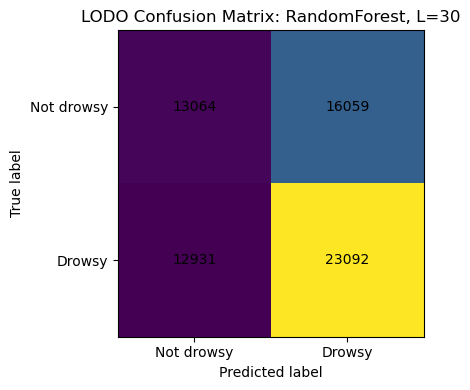

In [17]:
# Select best configuration by mean F1 for drowsy class, then AUROC
best_row = all_fold_results.groupby(["seq_len", "model"])[["f1_drowsy", "auroc", "accuracy"]].mean().sort_values(["f1_drowsy", "auroc"], ascending=False).head(1)
print("Best configuration:")
display(best_row)

best_seq_len, best_model = best_row.index[0]
print("Best seq_len:", best_seq_len, "Best model:", best_model)

# Combine predictions from matching model
pred_frames = []
if 'preds_df' in globals() and len(preds_df): pred_frames.append(preds_df)
if 'deep_preds_df' in globals() and len(deep_preds_df): pred_frames.append(deep_preds_df)
all_preds = pd.concat(pred_frames, ignore_index=True)
all_preds.to_csv(OUT_DIR / "all_lodo_predictions.csv", index=False)

best_preds = all_preds[(all_preds["seq_len"] == best_seq_len) & (all_preds["model"] == best_model)]
cm = confusion_matrix(best_preds["y_true"], best_preds["y_pred"])
print(cm)
print(classification_report(best_preds["y_true"], best_preds["y_pred"], target_names=["Not drowsy", "Drowsy"], zero_division=0))
save_confusion_matrix(cm, f"LODO Confusion Matrix: {best_model}, L={best_seq_len}", OUT_DIR / "best_confusion_matrix.png")

## 11. Manuscript-ready interpretation notes

After running all cells, use the saved files in `results_clean` for the Results section:

- `summary_results.csv`: main comparison table.
- `all_lodo_fold_results.csv`: fold-level results.
- `all_lodo_predictions.csv`: all predictions.
- `best_confusion_matrix.png`: confusion matrix for the best model.

The manuscript should only claim models and protocols that appear in these outputs.